# Session 2: Spatial autocorrelation, diffusion, and a capstone

Same graph as Session 1. Nothing here rebuilds it from scratch.

### Instructor notes

The student file, plus a worked capstone that has actually been run with its margin
reported, and an `# INSTRUCTOR` block at the top of every code cell saying what the cell
does and what is worth saying about it. The runnable student code is identical to
`session2.ipynb`.

**Clock.** Section 2 at 0:10, 3 at 0:45, 4 at 1:35, 5 at 2:15. Section 3 will overrun
if you let
the Euler stability cell turn into a numerical-methods lecture; the threshold is on
the slide, the cell only has to show it being crossed.

**Cut first, in this order:** the Moran scatterplot in section 2 (the permutation
histogram is the block's argument, not the scatterplot), and the Fiedler-overlay
closing cell in section 3. Both are marked below.

**Do not** cut the multiple-comparison cell. The Bonferroni line prints zero significant
regions, and the reason is not that the map is flat. A permutation p-value has a floor at
1/(permutations + 1), and Bonferroni at n = 162 is asking for a number that 999
permutations cannot produce. It is the most useful cell in the block.

In [1]:
# INSTRUCTOR
# Same Colab guard as Session 1. If the room already has Session 1 running, this is a
# no-op locally and takes about a minute on Colab.
# Note that Colab sessions started fresh will NOT have session1_state.npz, so the reload
# cell below will take its recompute branch. That is expected and costs a few seconds.

# Colab only. Locally this is a no-op and prints nothing.
# Identical to the first cell of Session 1: on Colab it installs the spatial stack and
# downloads the two data files, on your own machine DATA already points at them.
import pathlib
import subprocess
import sys
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/farrencc/dist_net_finder/main/graph-workshop"
DATA = pathlib.Path("../data")

if "google.colab" in sys.modules:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "geopandas==1.1.4", "libpysal==4.14.1", "esda==2.9.0", "splot==1.1.7",
         "osmnx==2.1.1", "mapclassify==2.10.0"],
        check=True,
    )
    DATA = pathlib.Path("data")
    DATA.mkdir(exist_ok=True)
    for fname in ("dublin_eds.gpkg", "streets.graphml"):
        urllib.request.urlretrieve(f"{REPO_RAW}/data/{fname}", DATA / fname)
    print("Colab setup done:", sorted(p.name for p in DATA.iterdir()))

In [2]:
# INSTRUCTOR
# SEED matches Session 1 so the labels line up; RNG is deliberately a different stream
# (20240402 rather than 20240401), since nothing here should reproduce Session 1's draws.
# ATTR must match whatever Session 1 used, or the cached labels will not correspond to
# the attribute being analysed here.

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from libpysal.weights import Queen
from scipy.linalg import eigh

# Same seeds and the same attribute as Session 1, so the numbers line up.
SEED = 7
RNG = np.random.default_rng(20240402)
ATTR = "pct_third_level"

plt.rcParams.update({
    "figure.figsize": (9.0, 5.0),
    "figure.dpi": 110,
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.constrained_layout.use": True,
})

## 0. Reload

`session1_state.npz` comes from Session 1, section 7. If it is missing, the two label
vectors are recomputed here instead and everything else is identical either way. The
cell prints which of the two it used.

In [3]:
# INSTRUCTOR
# Section 0 rebuilds Session 1 in about ten seconds. Run it while talking; nothing here
# is worth narrating line by line.
# The eigh(L) call takes the FULL spectrum, not just lambda_2, because section 3 expands
# the diffusion over every mode. At n = 162 that is instant.
# The cache branch is a convenience, not a dependency: if session1_state.npz is missing
# (a fresh Colab kernel, or a student who skipped the save cell), the labels are
# recomputed from the same inputs and the printed source line says so. Glance at that
# line, because a room split between the two paths should still see identical numbers.
# The spot check exists for the same reason as Session 1's assert: node order must equal
# GeoDataFrame row order or every map is drawn onto the wrong polygons.

# Rebuild the Session 1 objects: the EDs, the Queen contiguity graph, the standardised
# attribute, and the full eigendecomposition of the unweighted Laplacian.
gdf = gpd.read_file(DATA / "dublin_eds.gpkg", layer="eds").to_crs(2157)
w = Queen.from_dataframe(gdf, use_index=False)
G = w.to_networkx()

n = len(gdf)
pts = gdf.geometry.representative_point()
POS = {i: (pts.iloc[i].x, pts.iloc[i].y) for i in range(n)}
nx.set_node_attributes(G, dict(zip(range(n), gdf["ED_ENGLISH"])), "name")

y = gdf[ATTR].to_numpy(float)
z = (y - y.mean()) / y.std(ddof=0)

# The full spectrum, not just lambda_2: section 3 needs every mode to run the diffusion.
L = nx.laplacian_matrix(G, nodelist=range(n)).toarray().astype(float)
evals, evecs = eigh(L)

cache = DATA / "session1_state.npz"
if cache.exists():
    state = np.load(cache, allow_pickle=True)
    SIGMA = float(state["sigma"])
    labels_unweighted = state["labels_unweighted"]
    labels_weighted = state["labels_weighted"]
    source = "session1_state.npz"
else:
    diffs = np.array([abs(z[i] - z[j]) for i, j in G.edges()])
    SIGMA = float(np.median(diffs))
    Wm = np.zeros((n, n))
    for i, j in G.edges():
        Wm[i, j] = Wm[j, i] = np.exp(-((z[i] - z[j]) ** 2) / (2 * SIGMA ** 2))
    Dm = np.diag(Wm.sum(axis=1))
    labels_unweighted = (evecs[:, 1] > 0).astype(int)
    labels_weighted = (eigh(Dm - Wm, Dm)[1][:, 1] > 0).astype(int)
    source = "recomputed (no cache found)"

print(f"{n} EDs, {G.number_of_edges()} contiguity edges, connected={nx.is_connected(G)}")
print(f"lambda_2 = {evals[1]:.5f}")
print(f"Session 1 labels from: {source}   sigma = {SIGMA:.3f}")
print("spot check:", [(i, G.nodes[i]['name'], gdf['ED_ENGLISH'].iloc[i]) for i in (0, 80, n - 1)])

162 EDs, 462 contiguity edges, connected=True
lambda_2 = 0.06089
Session 1 labels from: session1_state.npz   sigma = 0.428
spot check: [(0, 'ARRAN QUAY A', 'ARRAN QUAY A'), (80, 'INNS QUAY B', 'INNS QUAY B'), (161, 'WOOD QUAY B', 'WOOD QUAY B')]


## 1. Recap (0:00)

Slides.

## 2. Moran's I (0:10)

$I = \dfrac{n}{\sum_{ij} w_{ij}} \cdot \dfrac{\sum_{ij} w_{ij} z_i z_j}{\sum_i z_i^2}$,
with $z$ the centred attribute.

In [4]:
# INSTRUCTOR
# The bridge between the two vocabularies. A spatial weights object and an adjacency
# matrix are the same thing; libpysal just calls it W and networkx calls it A.
# transform = 'b' gives back the binary adjacency, and the array_equal check proves it.
# transform = 'r' row-standardises, so every row sums to 1 and each ED's spatial lag is
# the plain mean of its neighbours. Moran's I below assumes this normalisation.
# Leave w in 'r' when you move on; the esda calls expect it.

# A spatial weights matrix and an adjacency matrix are the same object under two names.
# 'b' is binary (the raw adjacency), 'r' is row-standardised so each row sums to 1,
# which is what Moran's I expects.
A = nx.adjacency_matrix(G, nodelist=range(n)).toarray()

w.transform = "b"
print("unstandardised W is the Session 1 adjacency matrix:", np.array_equal(w.full()[0].astype(int), A))

w.transform = "r"
print("row sums after 'r':", np.unique(np.round(w.full()[0].sum(axis=1), 12)))

unstandardised W is the Session 1 adjacency matrix: True
row sums after 'r': [1.]


In [5]:
# INSTRUCTOR
# Three things in the printed output, in order of how often they are got wrong.
# 1. E[I] is -1/(n-1) = -0.0062, not zero. Under the null the mean is slightly negative,
#    because each value appears in its own neighbours' lags.
# 2. Inference is by permutation. There is a normal approximation, but the assumptions
#    behind it are exactly the ones spatial data violates, so permute instead.
# 3. p_sim of 0.001 is the floor for 999 permutations, not a precise probability. It
#    means "not one of 999 shuffles beat it", which is the honest reading and the setup
#    for the multiple-comparison cell two below.

from esda import Moran

PERMUTATIONS = 999
ALPHA = 0.05

# Moran's I: the correlation between each ED's value and the average of its neighbours.
# Significance comes from permutations, not from a normal table, because the values are
# not independent draws and no closed-form null applies.
mi = Moran(y, w, permutations=PERMUTATIONS)
print(f"I      = {mi.I:+.4f}")
print(f"E[I]   = {mi.EI:+.4f}   (= -1/(n-1) = {-1 / (n - 1):+.4f}, not zero)")
print(f"z-score= {mi.z_sim:+.2f}")
print(f"p_sim  = {mi.p_sim:.4f}   ({PERMUTATIONS} permutations, alpha = {ALPHA})")

I      = +0.7176
E[I]   = -0.0062   (= -1/(n-1) = -0.0062, not zero)
z-score= +15.61
p_sim  = 0.0010   (999 permutations, alpha = 0.05)


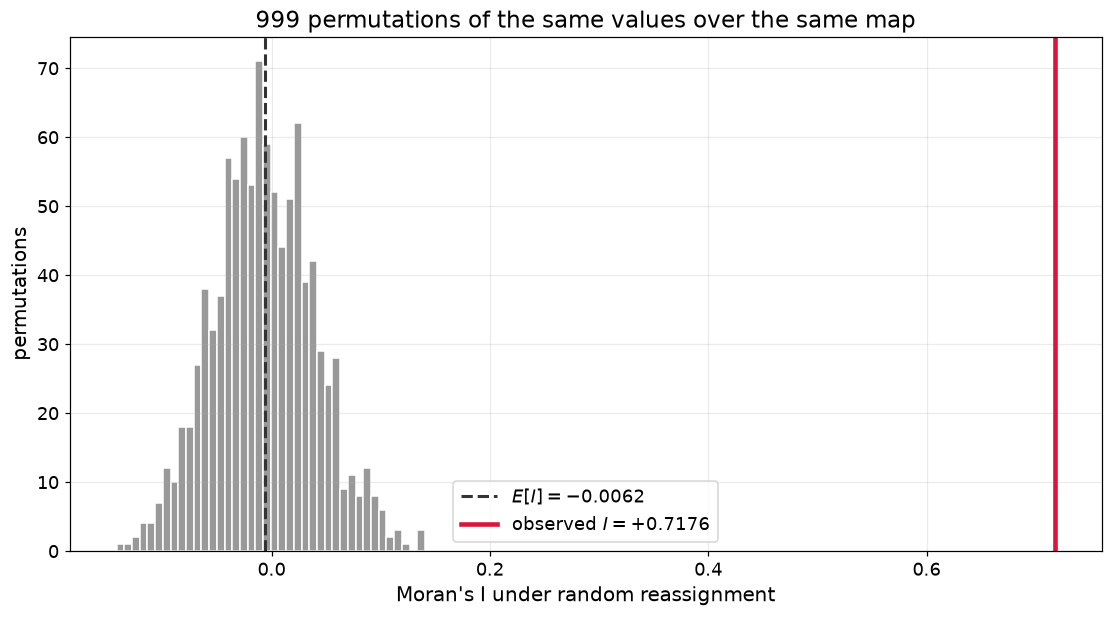

In [6]:
# INSTRUCTOR
# The clearest slide in the block. The grey histogram is 999 reshufflings of the SAME
# values over the SAME map, so the map, the graph and the marginal distribution are all
# held fixed and only the pairing is broken.
# The observed I sits far off the right-hand tail. Say explicitly that this is what a
# permutation test is: build the world where your effect does not exist, and look.

# The null distribution, built by shuffling the same values over the same map 999 times.
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(mi.sim, bins=40, color="0.6", edgecolor="white")
ax.axvline(mi.EI, color="0.2", ls="--", lw=2, label=rf"$E[I] = {mi.EI:+.4f}$")
ax.axvline(mi.I, color="crimson", lw=3, label=rf"observed $I = {mi.I:+.4f}$")
ax.set_xlabel("Moran's I under random reassignment")
ax.set_ylabel("permutations")
ax.set_title(f"{PERMUTATIONS} permutations of the same values over the same map")
ax.legend()
plt.show()

**Cut first if behind.** The Moran scatterplot. The permutation histogram above already made the argument.

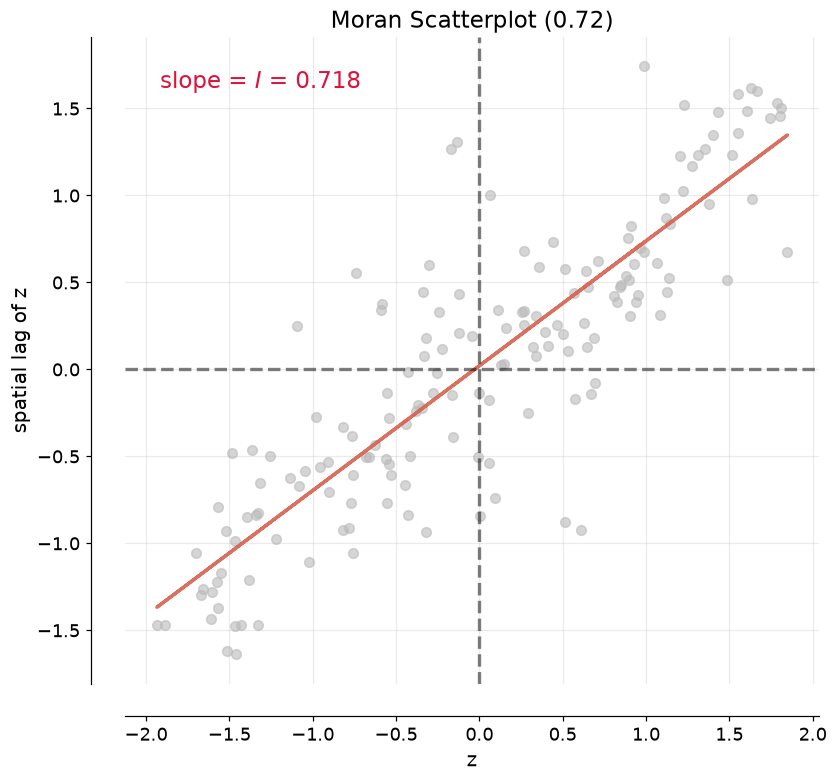

In [7]:
# INSTRUCTOR
# CUT FIRST IF BEHIND (this cell). x is z, y is the spatial lag of z, and the slope of
# the fitted line is exactly I, which is the useful thing to be able to say.
# The quadrants prefigure the LISA categories: upper right HH, lower left LL, and the
# off-diagonal quadrants are the spatial outliers. If you keep the cell, name the
# quadrants now and the LISA map two cells later needs no explanation.

# Each ED plotted against the average of its neighbours. The slope of the fit IS I.
from splot.esda import moran_scatterplot

fig, ax = plt.subplots(figsize=(7.5, 7))
moran_scatterplot(mi, ax=ax, aspect_equal=False)
ax.set_xlabel("z")
ax.set_ylabel("spatial lag of z")
ax.annotate(rf"slope = $I$ = {mi.I:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
            fontsize=15, color="crimson")
plt.show()

In [8]:
# INSTRUCTOR
# DO NOT CUT. This is the most useful cell in the block.
# 162 local tests instead of one global one, so roughly 8 will pass at alpha = 0.05 by
# chance alone. Raw gives about 30 significant, BH cuts it, Bonferroni gives 0.
# The Bonferroni zero is the payoff and the reason is NOT that the map is flat. It is
# that a permutation p-value cannot go below 1/(permutations + 1) = 1e-3, while
# Bonferroni is asking for p < 0.05/162 = 3.1e-4. No number of EDs could pass; the test
# is asking for a resolution 999 permutations do not have.
# The fix, if someone asks, is more permutations (99999 would do it), not a different
# correction. Ask the room what they would have concluded from the zero without this.

from esda import Moran_Local

# Moran's I was one test on the whole map. LISA is one test per ED, so 162 tests,
# and about 8 of them will look significant at alpha = 0.05 through luck alone.
lisa = Moran_Local(y, w, permutations=PERMUTATIONS, seed=SEED)


# Benjamini-Hochberg controls the false discovery rate: sort the p-values and keep
# everything up to the largest one still under alpha * rank / m.
def benjamini_hochberg(p, alpha):
    order = np.argsort(p)
    m = p.size
    passed = p[order] <= alpha * np.arange(1, m + 1) / m
    keep = np.zeros(m, dtype=bool)
    if passed.any():
        keep[order[: np.max(np.nonzero(passed)) + 1]] = True
    return keep


raw_sig = lisa.p_sim < ALPHA
bh_sig = benjamini_hochberg(lisa.p_sim, ALPHA)

print(f"significant at alpha = {ALPHA}          : {raw_sig.sum():3d} / {n}")
print(f"after Benjamini-Hochberg (FDR = {ALPHA}) : {bh_sig.sum():3d} / {n}")
print(f"after Bonferroni (alpha/n = {ALPHA / n:.2e}) : {(lisa.p_sim < ALPHA / n).sum():3d} / {n}")
# A permutation p-value has a hard floor at 1/(permutations + 1). Bonferroni at this n
# is asking for a number that 999 permutations simply cannot produce, so the zero it
# reports is a property of the test setup and not a statement about Dublin.
print(f"smallest p_sim {PERMUTATIONS} permutations can produce : {1 / (PERMUTATIONS + 1):.2e}")

significant at alpha = 0.05          :  69 / 162
after Benjamini-Hochberg (FDR = 0.05) :  43 / 162
after Bonferroni (alpha/n = 3.09e-04) :   0 / 162
smallest p_sim 999 permutations can produce : 1.00e-03


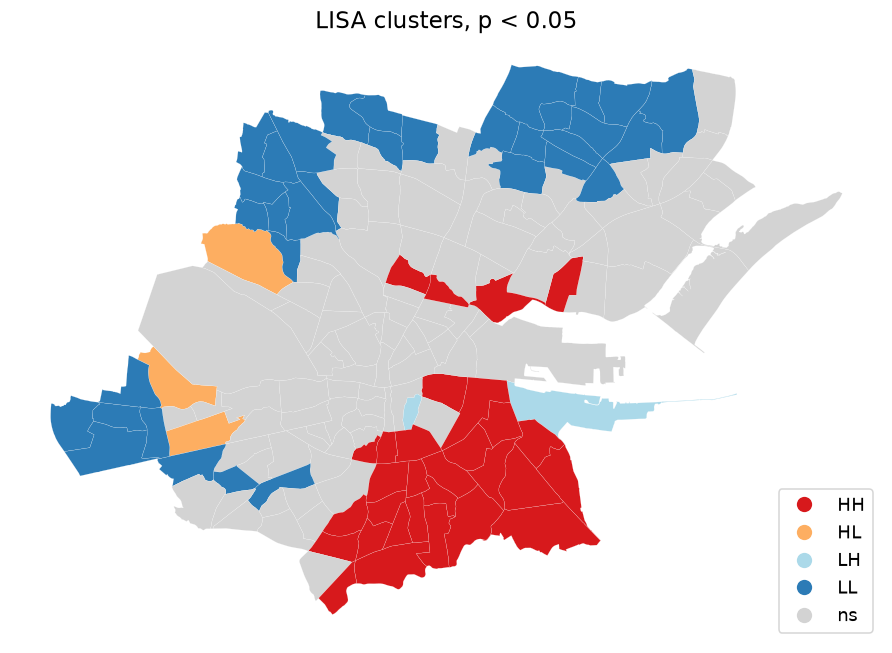

In [9]:
# INSTRUCTOR
# The standard splot LISA map, uncorrected, at p < 0.05. Show it, then point out that
# by the cell above roughly eight of these patches are noise, and that this is the map
# that normally appears in papers without the caveat.
# HH and LL are clusters; HL and LH are single EDs unlike their neighbours, which on
# this attribute usually means an institutional or industrial division.

# HH and LL are clusters, HL and LH are spatial outliers: one ED unlike its neighbours.
from splot.esda import lisa_cluster

fig, ax = plt.subplots(figsize=(8, 9))
lisa_cluster(lisa, gdf, p=ALPHA, ax=ax, legend_kwds={"loc": "lower right"})
ax.set_axis_off()
ax.set_title(f"LISA clusters, p < {ALPHA}")
plt.show()

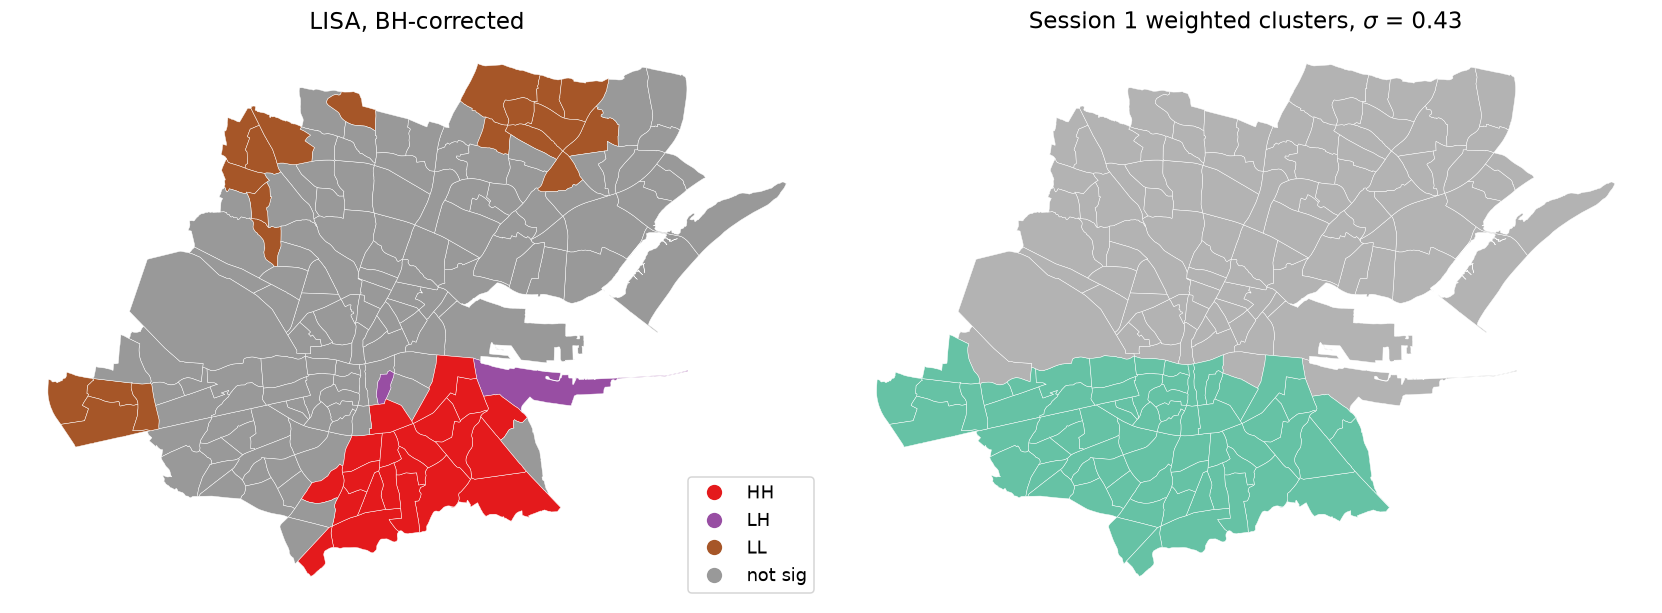

In [10]:
# INSTRUCTOR
# Left: LISA after BH correction. Right: the Session 1 weighted clusters.
# Two quite different questions on the same data. LISA asks "is this ED unusual given
# its neighbours", and the spectral cut asks "where does the whole map divide". They
# are not the same statement, and neither one validates the other.
# The overlap is real but partial, which is the honest answer and the right note on
# which to go into the capstone.

# The corrected LISA map beside the Session 1 weighted clusters. Two different methods,
# same graph, same attribute: worth seeing where they agree and where they do not.
QUAD = {0: "not sig", 1: "HH", 2: "LH", 3: "LL", 4: "HL"}
quad = np.where(bh_sig, lisa.q, 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
gdf.assign(_q=[QUAD[v] for v in quad]).plot(column="_q", categorical=True, cmap="Set1",
                                            legend=True, edgecolor="white", linewidth=0.3,
                                            ax=axes[0], legend_kwds={"loc": "lower right"})
axes[0].set_title("LISA, BH-corrected")
gdf.assign(_l=labels_weighted).plot(column="_l", categorical=True, cmap="Set2",
                                    edgecolor="white", linewidth=0.3, ax=axes[1])
axes[1].set_title(rf"Session 1 weighted clusters, $\sigma$ = {SIGMA:.2f}")
for ax in axes:
    ax.set_axis_off()
plt.show()

In [11]:
# INSTRUCTOR
# The same comparison as counts. Expect most of the significant HH cells in one cluster
# and most of the LL cells in the other, with a large "not sig" row spread over both.
# That spread is the point: the spectral method commits everywhere, LISA does not.

# The same agreement as a table rather than as two maps.
print(pd.crosstab(pd.Series(labels_weighted, name="cluster"),
                  pd.Series([QUAD[v] for v in quad], name="LISA")))

LISA     HH  LH  LL  not sig
cluster                     
0        21   1   4       40
1         0   1  16       79


## 3. Diffusion (0:45)

$\dfrac{du_i}{dt} = \sum_{j \sim i} (u_j - u_i)$, which is $\dot{u} = -Lu$.

In [12]:
# INSTRUCTOR
# Ten seconds, and it earns the rest of the section. The written-out rule "each ED gains
# the difference between it and each neighbour" is a loop anyone can read, and it agrees
# with -L u to 1e-15.
# So the Laplacian was never an abstraction; it is the bookkeeping for that loop. On a
# random test vector rather than a tidy one, so the agreement cannot be a coincidence.

# Sanity check before trusting anything below: the plain-English rule "each ED moves
# towards the average of its neighbours", written as a loop, is exactly -L u.
u_test = RNG.normal(size=n)
by_hand = np.array([sum(u_test[j] - u_test[i] for j in G[i]) for i in range(n)])

print("max |loop - (-L u)| =", np.abs(by_hand - (-L @ u_test)).max())

max |loop - (-L u)| = 3.552713678800501e-15


In [13]:
# INSTRUCTOR
# The source is chosen, not arbitrary: the highest-betweenness ED, the same one mapped
# in Session 1 section 6. Releasing at the best-connected node makes the capstone test as
# generous as possible to the mass escaping, which strengthens the eventual result.
# Print the Fiedler entry too. It says which side of the Session 1 line the mass starts
# on, and that is the `side` argument leakage() will need.

# Release the mass at the best-connected ED, so the test is as favourable as possible
# to the mass getting out. Its Fiedler entry tells us which side of the line it starts on.
betweenness = nx.betweenness_centrality(G)
SHOCK = max(betweenness, key=betweenness.get)

print(f"shock at node {SHOCK}: {G.nodes[SHOCK]['name']}")
print(f"  betweenness {betweenness[SHOCK]:.4f} (rank 1 of {n}), degree {G.degree(SHOCK)}")
print(f"  Fiedler entry {evecs[SHOCK, 1]:+.4f}")

shock at node 48: CLONTARF WEST D
  betweenness 0.2597 (rank 1 of 162), degree 9
  Fiedler entry -0.0453


In [14]:
# INSTRUCTOR
# The core of the section. Two ideas.
# TAU = 1/lambda_2 is the graph's natural clock, the decay time of the slowest
# non-constant mode. All times are quoted as multiples of it so the numbers transfer to
# a graph of any size, which is worth saying explicitly.
# diffuse() solves u' = -L u exactly: expand u0 in the eigenvectors, scale each
# coefficient by exp(-lambda_k t), transform back. No timestep and no stability limit,
# which is only affordable because we already have the full spectrum from section 0.
# In the printout, sum u stays at 1.000000000000 at every time. Point at it. Mass is
# conserved because lambda_1 = 0 with a constant eigenvector, so the mean cannot decay.
# It is also what makes leakage() in the capstone a fraction rather than a raw quantity.

# TAU = 1/lambda_2 is the natural clock of the graph: the decay time of the slowest
# non-constant mode. Times are quoted as multiples of it so they transfer to other graphs.
TAU = 1.0 / evals[1]
TIMES = [m * TAU for m in (0.02, 0.05, 0.12, 0.30, 1.00)]

u0 = np.zeros(n)
u0[SHOCK] = 1.0
coeffs = evecs.T @ u0


# Solve u' = -L u exactly rather than stepping it: expand the initial state in the
# eigenvectors, multiply each coefficient by exp(-lambda_k t), and transform back.
# No timestep, no stability condition, valid at any t.
def diffuse(source_node, t):
    """State of the graph heat equation at time t, unit mass released at source_node."""
    c = evecs.T[:, source_node]
    return evecs @ (np.exp(-evals * t) * c)


print(f"tau = 1/lambda_2 = {TAU:.2f}")
for t in TIMES:
    u = diffuse(SHOCK, t)
    print(f"  t = {t:8.3f}   sum u = {u.sum():.12f}   max u = {u.max():.4f}")

tau = 1/lambda_2 = 16.42
  t =    0.328   sum u = 1.000000000000   max u = 0.1105
  t =    0.821   sum u = 1.000000000000   max u = 0.0507
  t =    1.971   sum u = 1.000000000000   max u = 0.0220
  t =    4.927   sum u = 1.000000000000   max u = 0.0105
  t =   16.422   sum u = 1.000000000000   max u = 0.0085


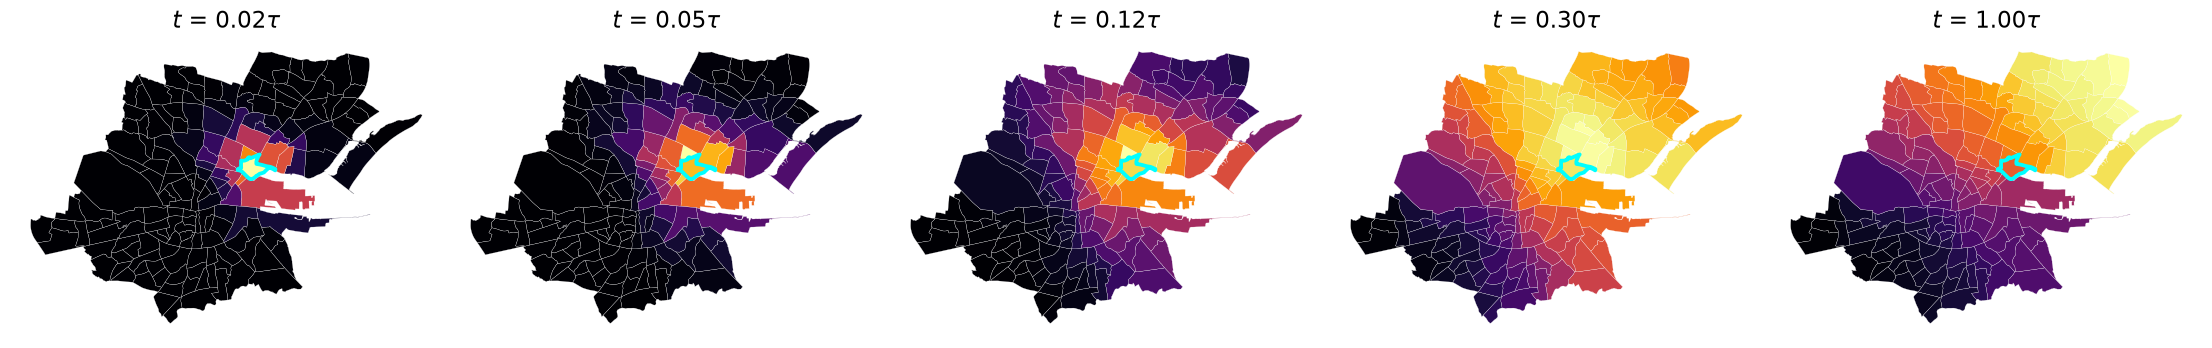

In [15]:
# INSTRUCTOR
# Five snapshots from 0.02 TAU to 1 TAU, cyan outline on the source.
# The trap to name before anyone falls into it: each panel is normalised to ITS OWN
# maximum, so the colours are not comparable across panels. They show where the front
# has reached, not how much is there. The conserved totals in the previous printout are
# the corrective, which is why that cell runs first.

# Each panel is scaled to its own maximum, so these show where the front has reached
# rather than how much is left. The totals are all exactly 1, as printed above.
# The cyan outline is the source ED.
fig, axes = plt.subplots(1, len(TIMES), figsize=(4 * len(TIMES), 5.5))
for ax, t in zip(axes, TIMES):
    gdf.assign(_u=diffuse(SHOCK, t)).plot(column="_u", cmap="inferno", ax=ax,
                                          edgecolor="white", linewidth=0.15)
    gdf.iloc[[SHOCK]].plot(ax=ax, facecolor="none", edgecolor="cyan", linewidth=2.5)
    ax.set_axis_off()
    ax.set_title(rf"$t$ = {t / TAU:.2f}$\tau$")
plt.show()

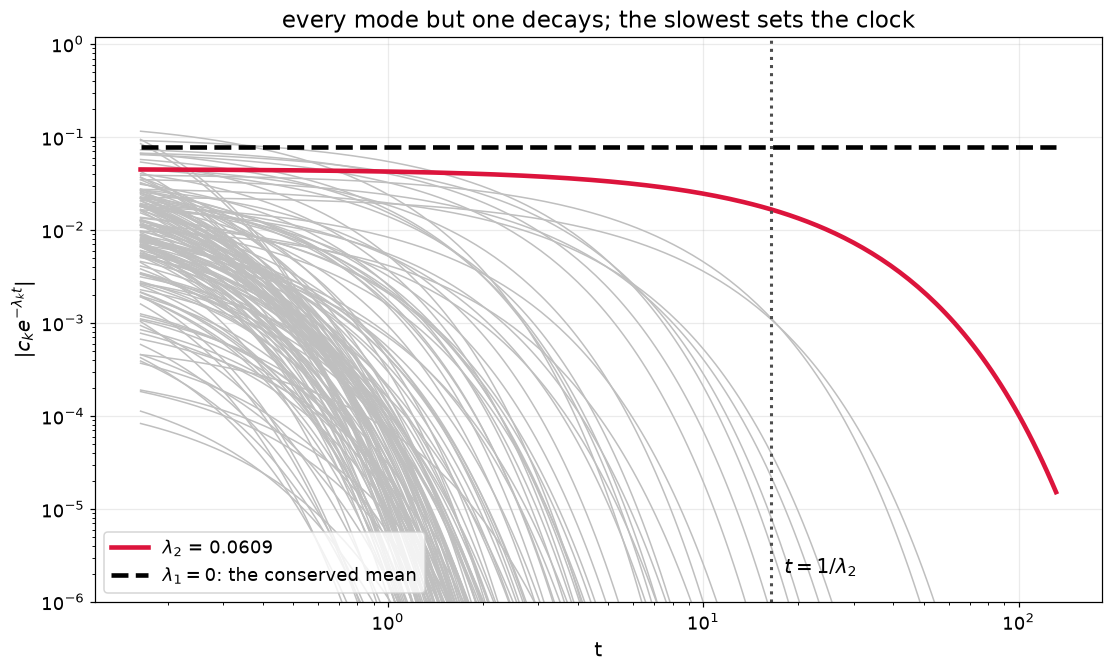

In [16]:
# INSTRUCTOR
# Log-log, one grey line per mode. Everything decays except the black dashed lambda_1 = 0
# line, which is the conserved mean, and the red lambda_2 line is the last of the
# decaying modes still alive.
# Read it left to right: early on, many modes contribute and the shape is complicated;
# by t = 1/lambda_2 essentially only lambda_1 and lambda_2 remain, so the state is the
# mean plus a multiple of the Fiedler vector.
# That is the answer to capstone hint 2, and it is why t = 1/lambda_2 is the defensible
# time to measure at. Do not give it away; make them come back to this figure.

# The same solution taken apart mode by mode: each one is a coefficient times
# exp(-lambda_k t), so large eigenvalues die first and lambda_1 = 0 never dies at all.
t_grid = np.geomspace(0.01 * TAU, 8 * TAU, 200)
amps = np.abs(coeffs[None, :] * np.exp(-evals[None, :] * t_grid[:, None]))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_grid, amps[:, 2:], color="0.75", lw=1.0)
ax.plot(t_grid, amps[:, 1], color="crimson", lw=3, label=rf"$\lambda_2$ = {evals[1]:.4f}")
ax.plot(t_grid, amps[:, 0], color="k", lw=3, ls="--", label=r"$\lambda_1 = 0$: the conserved mean")
ax.axvline(TAU, color="0.3", ls=":", lw=2)
ax.text(TAU * 1.1, 2e-6, r"$t = 1/\lambda_2$", fontsize=13)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-6, 1.2)
ax.set_xlabel("t")
ax.set_ylabel(r"$|c_k e^{-\lambda_k t}|$")
ax.set_title(r"every mode decays except $\lambda_1$, and $\lambda_2$ decays slowest")
ax.legend(loc="lower left")
plt.show()

In [17]:
# INSTRUCTOR
# Three routes to the same state, agreeing to about 1e-15 (expm against eigh) and about
# 1e-3 (Euler, which is first order and has genuine truncation error).
# Keep this short. Its only job is to establish that diffuse() is trustworthy before the
# capstone leans on it, and to set up the stability cell below.

# Three routes to the same state: the matrix exponential, our eigendecomposition,
# and explicit Euler with a safe timestep. They should agree to near machine precision.
from scipy.linalg import expm

t_check = 0.5 * TAU
u_expm = expm(-L * t_check) @ u0
u_eig = diffuse(SHOCK, t_check)

dt = 0.5 * 2.0 / evals[-1]
u_euler = u0.copy()
for _ in range(int(round(t_check / dt))):
    u_euler = u_euler - dt * (L @ u_euler)

print(f"expm vs eigendecomposition : {np.abs(u_expm - u_eig).max():.3e}")
print(f"expm vs Euler (dt = {dt:.4f}) : {np.abs(u_expm - u_euler).max():.3e}")

expm vs eigendecomposition : 9.281e-17
expm vs Euler (dt = 0.0792) : 3.917e-05


lambda_max      = 12.626
2 * max degree  = 22   (the bound lambda_max cannot exceed)
stable dt       < 0.1584


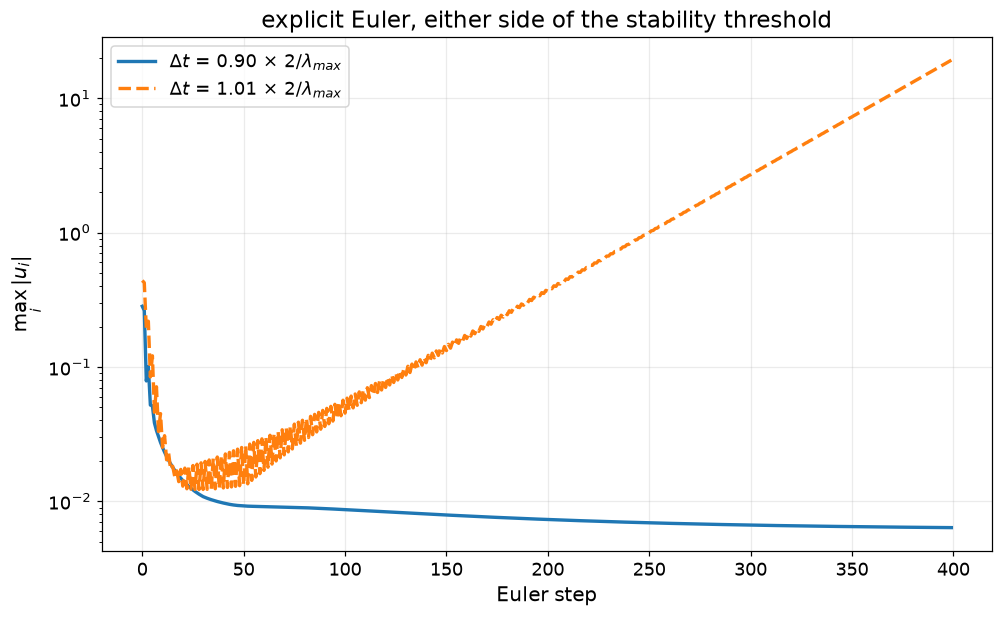

In [18]:
# INSTRUCTOR
# WATCH THE CLOCK HERE. This cell reliably turns into a numerical-methods lecture and
# section 3 overruns as a result. The threshold is already on the slide; the cell only
# has to show it being crossed.
# Explicit Euler is stable for dt < 2/lambda_max. Below it the solid line decays, a
# fraction above it the dashed line grows without bound, on a log axis, immediately.
# One sentence of connection and move on: lambda_max <= 2 * max degree, so the densest
# node in the graph sets the largest timestep the whole simulation may take. That is a
# graph property dictating a numerical one, which is the transferable idea.

# Explicit Euler on u' = -L u is stable only for dt < 2/lambda_max. Since
# lambda_max <= 2 * max degree, the graph itself dictates the largest usable timestep.
dt_max = 2.0 / evals[-1]
print(f"lambda_max      = {evals[-1]:.3f}")
print(f"2 * max degree  = {2 * max(d for _, d in G.degree())}   (the bound lambda_max cannot exceed)")
print(f"stable dt       < {dt_max:.4f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
for factor, style in [(0.9, "-"), (1.01, "--")]:
    step = factor * dt_max
    u = u0.copy()
    trace = []
    for _ in range(400):
        u = u - step * (L @ u)
        trace.append(np.abs(u).max())
    ax.semilogy(trace, style, label=rf"$\Delta t$ = {factor:.2f} $\times$ 2/$\lambda_{{max}}$")
ax.set_xlabel("Euler step")
ax.set_ylabel(r"$\max_i |u_i|$")
ax.set_title("explicit Euler, either side of the stability threshold")
ax.legend()
plt.show()

**Cut first if behind.** The Fiedler boundary drawn on the late-time snapshot. Nice to have; the capstone does not need it.

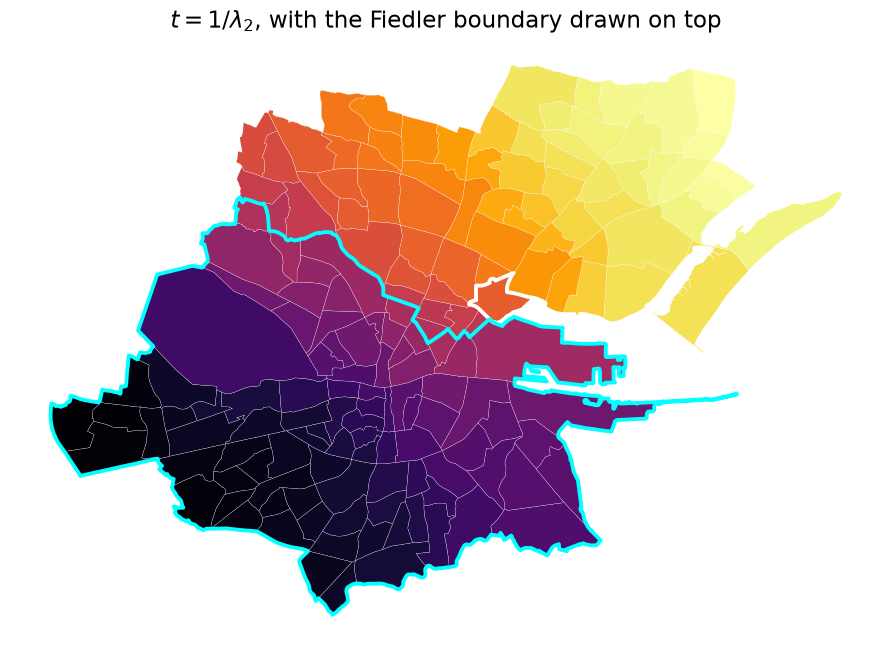

In [19]:
# INSTRUCTOR
# CUT FIRST IF BEHIND (this cell). The t = 1/lambda_2 snapshot with the Session 1 Fiedler
# boundary dissolved into a single cyan line on top.
# It is the capstone question asked as a picture: the hot region visibly stops near the
# line. Nice to have and genuinely motivating, but the capstone does not need it, and a
# student who has not seen it is not disadvantaged.

# The late-time snapshot with the Session 1 Fiedler boundary drawn over it.
# This is the capstone question posed as a picture: has the mass crossed the cyan line?
fig, ax = plt.subplots(figsize=(8, 9))
gdf.assign(_u=diffuse(SHOCK, 1.0 * TAU)).plot(column="_u", cmap="inferno", ax=ax,
                                              edgecolor="white", linewidth=0.15)
gdf[evecs[:, 1] > 0].dissolve().boundary.plot(ax=ax, color="cyan", linewidth=2.5)
gdf.iloc[[SHOCK]].plot(ax=ax, facecolor="none", edgecolor="white", linewidth=2.5)
ax.set_axis_off()
ax.set_title(r"$t = 1/\lambda_2$, with the Fiedler boundary drawn on top")
plt.show()

## 4. Capstone (1:35)

### The question

In Session 1 you drew a line across Dublin using nothing but the second eigenvector of a
weighted Laplacian. It is a boundary in the sense that an algorithm chose to cut there.
Whether it is a boundary in any physical sense is a different question, and it is the one
you are answering now: **if something spreads across the contiguity graph, does that line
slow it down?**

### What you already have in memory

`diffuse(source_node, t)` releases one unit of mass at a single ED and returns where that
mass has reached at time `t`, using the eigendecomposition from section 3. Total mass is
conserved, so whatever time you ask for, the 162 numbers add to 1.

`labels_unweighted` and `labels_weighted` are the two Session 1 partitions of the same 162
EDs, each an array of 0s and 1s. The first used geometry only, the second used geometry
and the census attribute together.

`SHOCK` is the highest-betweenness ED, the natural place to release the mass.

`TAU`, `evals`, `evecs`, `G`, `gdf` and `n` are all still live from section 3.

### What you are being asked to build

Four steps, in the code cell below.

**1. Pick a time.** Leakage measured at t = 0 is zero and leakage measured at very large t
is whatever the equilibrium happens to be, so the answer depends entirely on when you
look. Choose one time and be ready to say why that one.

**2. Measure the real boundary.** Run the diffusion from `SHOCK` to your chosen time, then
use `leakage()` to get the fraction of mass that has ended up on the far side of the
Session 1 partition. That single number is your observed statistic. Do it for
`labels_weighted`, and for `labels_unweighted` too if you have time.

**3. Build a null.** One number on its own says nothing: 0.32 is neither large nor small
until there is something to compare it with. Generate many alternative boundaries that
match the real one in every respect you do not care about (the same graph, the same
source, the same number of EDs on the far side) and differ in the one respect you do
(they are not the spectral cut). Measure leakage across each of them in exactly the same
way. `random_contiguous_partition()` is there to draw them.

**4. Compare and report.** Where does the observed number sit inside the null
distribution? Count how many null draws leak less than the real boundary does. That rank
gives a p-value of `(rank + 1) / (draws + 1)`. Then fill in the conclusion cell below.

### What a good answer looks like

Not a small p-value. A good answer is one where you can state what your null holds fixed
and what it varies, and where the summary you quote matches the shape of the distribution
it came from. If the null comes out skewed, a z-score will flatter you and a percentile
will not.

Work on your own. The hints below are in order, so open them one at a time. The two
functions in the next cell are the whole toolkit.

In [20]:
# INSTRUCTOR
# The toolkit cell, and the last one you narrate before they work alone. Give them the
# markdown above properly, then read this cell out loud; it is the whole API.
# leakage(u, labels, side): mass on the far side. Total mass is 1, so the return value is
# already a fraction. `side` is the SOURCE's label, i.e. labels[SHOCK], and getting that
# backwards is the most common mistake in the room. The self-test below prints both ways
# round summing to 1, which is the diagnostic to point them at.
# random_contiguous_partition: grows a connected region of exactly `size` from a random
# seed by repeatedly absorbing a frontier node. Uses sorted(frontier) before indexing,
# because set iteration order is not reproducible and the results would not replay.
# Note the deliberate gap: it takes no exclusion argument, so it can hand back a region
# containing SHOCK. Students who hit that should notice the source must sit outside the
# region being tested. The worked solution below redraws until it does.
# The self-test checks size, connectivity, distinctness and coverage. If "EDs never
# included" is large, the growth is biased and the null is not doing its job.

def leakage(u, labels, side):
    """Mass sitting on the far side of the partition, given the source's side.

    `side` is the label of the side the source started on, so pass labels[SHOCK].
    Total mass is 1, so the answer is directly the fraction that crossed.
    """
    return float(u[labels != side].sum())


def random_contiguous_partition(G, size, rng=RNG, max_tries=500):
    """A connected set of exactly `size` nodes, grown from a random seed.

    Picks a start node at random, then repeatedly absorbs a random node from
    the current frontier. Retries from a new seed if the frontier ever empties
    before the region is full.
    """
    nodes = list(G)
    if not 0 < size <= len(nodes):
        raise ValueError(f"size must be in 1..{len(nodes)}, got {size}")
    for _ in range(max_tries):
        region = {nodes[rng.integers(len(nodes))]}
        frontier = set(G[next(iter(region))])
        while len(region) < size and frontier:
            pick = sorted(frontier)[rng.integers(len(frontier))]
            region.add(pick)
            frontier.discard(pick)
            frontier |= set(G[pick]) - region
        if len(region) == size:
            return np.array(sorted(region))
    raise RuntimeError(f"could not grow a connected region of {size} in {max_tries} tries")


# Already in scope, nothing to rebuild: diffuse(source_node, t), G, gdf, evals, evecs,
# TAU, labels_unweighted, labels_weighted, SHOCK, n

# Everything below this line is a self-test of the two functions, so you can see what
# they return before you build anything on them.

_probe = [random_contiguous_partition(G, 40) for _ in range(200)]
print("200 draws of size 40:")
print("  all the right size :", all(len(r) == 40 for r in _probe))
print("  all connected      :", all(nx.is_connected(G.subgraph(r)) for r in _probe))
print("  distinct regions   :", len({tuple(r) for r in _probe}), "of 200")
print("  EDs never included :", n - len(set(np.concatenate(_probe))))
print("  cluster sizes     :", np.bincount(labels_weighted))

_demo = np.zeros(n, dtype=int)
_demo[random_contiguous_partition(G, 40)] = 1
_u = diffuse(SHOCK, 0.1 * TAU)
print(f"leakage() over one such region, either way round, at t = 0.1 tau:"
      f" {leakage(_u, _demo, 0):.4f} + {leakage(_u, _demo, 1):.4f} = {_u.sum():.4f}")

200 draws of size 40:
  all the right size : True
  all connected      : True
  distinct regions   : 200 of 200
  EDs never included : 0
  cluster sizes     : [66 96]
leakage() over one such region, either way round, at t = 0.1 tau: 0.1757 + 0.8243 = 1.0000


<details><summary><b>Hint 1</b></summary>

Total `u` is conserved and starts at 1, so "how much crossed" is a sum over the far side.

</details>

<details><summary><b>Hint 2</b></summary>

Why $t = 1/\lambda_2$ and not any other time? Look again at the modal amplitude
plot in section 3 and ask what is still alive at that moment.

</details>

<details><summary><b>Hint 3</b></summary>

For a null: keep the cluster sizes, scatter the labels randomly across the map.

</details>

<details><summary><b>Hint 4</b></summary>

That null is weak. Scattered labels form no boundary at all, so almost anything beats
it. Grow a region out from a random seed to the same size instead, and you are comparing
against a real but arbitrary division of the city.

</details>

In [21]:
# INSTRUCTOR
# Forty minutes of independent work starts here. Hand out hints 1 to 4 in order and
# resist giving hint 4 early; the comparison between the two nulls is the lesson.
# Circulate for these four failure modes:
#  - leakage() called with the wrong `side`, giving 1 minus the intended answer;
#  - a null region that happens to contain SHOCK, which makes leakage meaningless;
#  - too few draws to resolve a rank-based p-value (fewer than a few hundred);
#  - a z-score quoted off a visibly skewed null, which is the discussion in the
#    worked solution below.
# The worked capstone, the numbers it produces and how to talk about them are all in the
# instructor-only section further down.

# ===========================================================================
# YOUR WORK
#
# Step 1. Pick a time and say why.
#   t = ...

# Step 2. Measure the real partition.
#   Run diffuse() from SHOCK to your time, then leakage() against labels_weighted.
#   Remember leakage() needs the source's own side, i.e. labels[SHOCK].

# Step 3. Build a null.
#   Draw many regions of the same size as the far side, measure each one the same way,
#   and collect the results in an array.

# Step 4. Compare.
#   rank = number of null draws that leak LESS than the real boundary
#   p    = (rank + 1) / (draws + 1)
#   Then plot the null distribution with the observed value marked on it.
# ===========================================================================

### Conclusion

**What I measured:**

**What I compared it against:**

**What I found:**

**What I would check next:**

### Worked capstone (instructor only)

Release unit mass at the highest-betweenness ED, run the diffusion to $t = 1/\lambda_2$,
and measure how much has crossed the Session 1 weighted-cluster boundary. Compare that
against the same measurement made on random contiguous regions of the same size.

In [22]:
# INSTRUCTOR
# The worked answer. Do not project this until they have had their forty minutes.
# T_STAR = TAU = 1/lambda_2, justified by the modal-decay figure in section 3: by that
# time only lambda_1 and lambda_2 are still alive, so the state is the mean plus a
# multiple of the Fiedler vector, and the Fiedler vector is what drew the boundary.
# Two nulls are built on purpose. The contiguous null grows a real region of the same
# size (hint 4). The scattered null keeps the same COUNT of far-side EDs but sprinkles
# them at random (hint 3), which forms no boundary at all and is far too easy to beat.
# _null_region redraws until SHOCK is outside the region, which is the gap left in the
# shipped random_contiguous_partition and a thing students have to notice for themselves.
# 1999 draws so that (rank + 1)/(draws + 1) can reach 0.0005; each pass is about a
# second. Drop to 499 if the laptop is slow, and quote the coarser p-value.
# `rank` counts null draws that leak LESS than the observed value, so rank 0 means
# nothing in the null held more back than the real boundary did.

T_STAR = TAU
u_star = diffuse(SHOCK, T_STAR)

DRAWS = 1999


def _null_region(size):
    # the shipped random_contiguous_partition takes no exclusion argument, so
    # redraw until the source is outside the region being tested
    while True:
        region = random_contiguous_partition(G, size)
        if SHOCK not in region:
            return region


results = {}
for name, labels in [("weighted", labels_weighted), ("unweighted", labels_unweighted)]:
    side = labels[SHOCK]
    observed = leakage(u_star, labels, side)
    size = int((labels != side).sum())

    contiguous = np.empty(DRAWS)
    scattered = np.empty(DRAWS)
    for d in range(DRAWS):
        lab = np.zeros(n, dtype=int)
        lab[_null_region(size)] = 1
        contiguous[d] = leakage(u_star, lab, 0)

        lab = np.ones(n, dtype=int)
        keep = RNG.choice(np.setdiff1d(np.arange(n), [SHOCK]), n - size - 1, replace=False)
        lab[np.append(keep, SHOCK)] = 0
        scattered[d] = leakage(u_star, lab, 0)

    rank = int((contiguous <= observed).sum())
    results[name] = (observed, contiguous, scattered, rank, size)

    print(f"{name} boundary, far side = {size} of {n} EDs")
    print(f"  observed leakage at t = 1/lambda_2      : {observed:.5f}")
    print(f"  contiguous null: min {contiguous.min():.5f}  median {np.median(contiguous):.5f}")
    print(f"  rank {rank} of {DRAWS}  ->  p = {(rank + 1) / (DRAWS + 1):.4f}")
    print(f"  scattered null : median {np.median(scattered):.5f}  (sd {scattered.std():.5f})")
    print()

weighted boundary, far side = 66 of 162 EDs
  observed leakage at t = 1/lambda_2      : 0.32351
  contiguous null: min 0.32420  median 0.35019
  rank 0 of 1999  ->  p = 0.0005
  scattered null : median 0.40670  (sd 0.00830)



unweighted boundary, far side = 94 of 162 EDs
  observed leakage at t = 1/lambda_2      : 0.48612
  contiguous null: min 0.48748  median 0.51806
  rank 0 of 1999  ->  p = 0.0005
  scattered null : median 0.57956  (sd 0.00827)



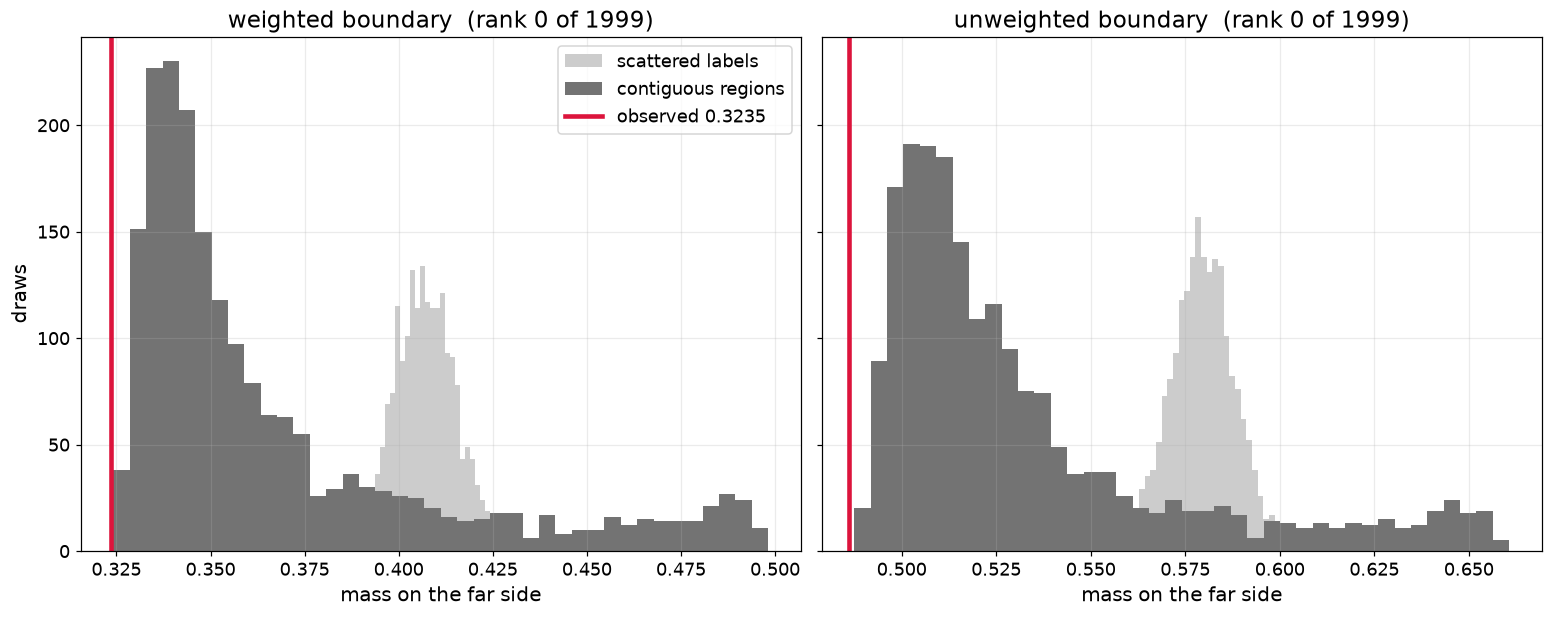

In [23]:
# INSTRUCTOR
# The figure to show while making the argument. Light grey is the scattered null, dark
# grey the contiguous null, red the observed value.
# Two things visible at a glance: the contiguous null sits far to the right of the
# scattered one (a real boundary of any shape holds back much more than scattered
# labels), and it is strongly right-skewed with a hard floor. The red line sits at or
# just below that floor.
# The skew is why the next cell insists on a percentile rather than a z-score, so leave
# the plot on screen while you say it.

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, name in zip(axes, results):
    observed, contiguous, scattered, rank, size = results[name]
    ax.hist(scattered, bins=40, color="0.8", label="scattered labels")
    ax.hist(contiguous, bins=40, color="0.45", label="contiguous regions")
    ax.axvline(observed, color="crimson", lw=3, label=f"observed {observed:.4f}")
    ax.set_xlabel("mass on the far side")
    ax.set_title(f"{name} boundary  (rank {rank} of {DRAWS})")
axes[0].set_ylabel("draws")
axes[0].legend(loc="upper right")
plt.show()

**Reading the result.**

Both Session 1 boundaries hold back more mass than every one of 1999 contiguous regions
of the same size. Rank 0, so $p = 0.0005$, which is the smallest number this null can
report. Treat it as a clear win, and expect students who follow hint 4 to land in the
same place.

Two things to have ready.

The margin is decisive in rank and tiny in magnitude: 0.3235 against a null minimum of
0.3242, about 0.2 % less mass across the line. When someone says "so it barely wins",
the answer is that the Fiedler cut is *defined* as the boundary the relaxed RatioCut
crosses least, so finding it at the extreme of the null is the theory doing exactly what
it claims. What the null adds is the knowledge that an arbitrary contiguous region of
the same size gets within a fraction of a percent of it. Most of the work is being done
by geography; the spectrum adds the rest.

A z-score against this null is misleading and someone will compute one. The contiguous
null is strongly right-skewed with a hard floor just above the observed value, so
$z \approx -1$ while the rank-based $p$ is 0.0005. Use that: on a skewed null, report
the percentile rather than the z-score.

A student who reports the scattered null instead (hint 3) gets $z \approx -10$ and a far
more impressive-looking answer out of a far weaker comparison. That inversion, where the
weaker null produces the better headline, is the discussion worth having.

### Angle B: does any of this survive losing the geography?

Same values, same map, shuffled between EDs.

Moran's I   before +0.7176 (p = 0.001)   after -0.0392 (p = 0.248)
cluster sizes before [66 96]   after [128  34]


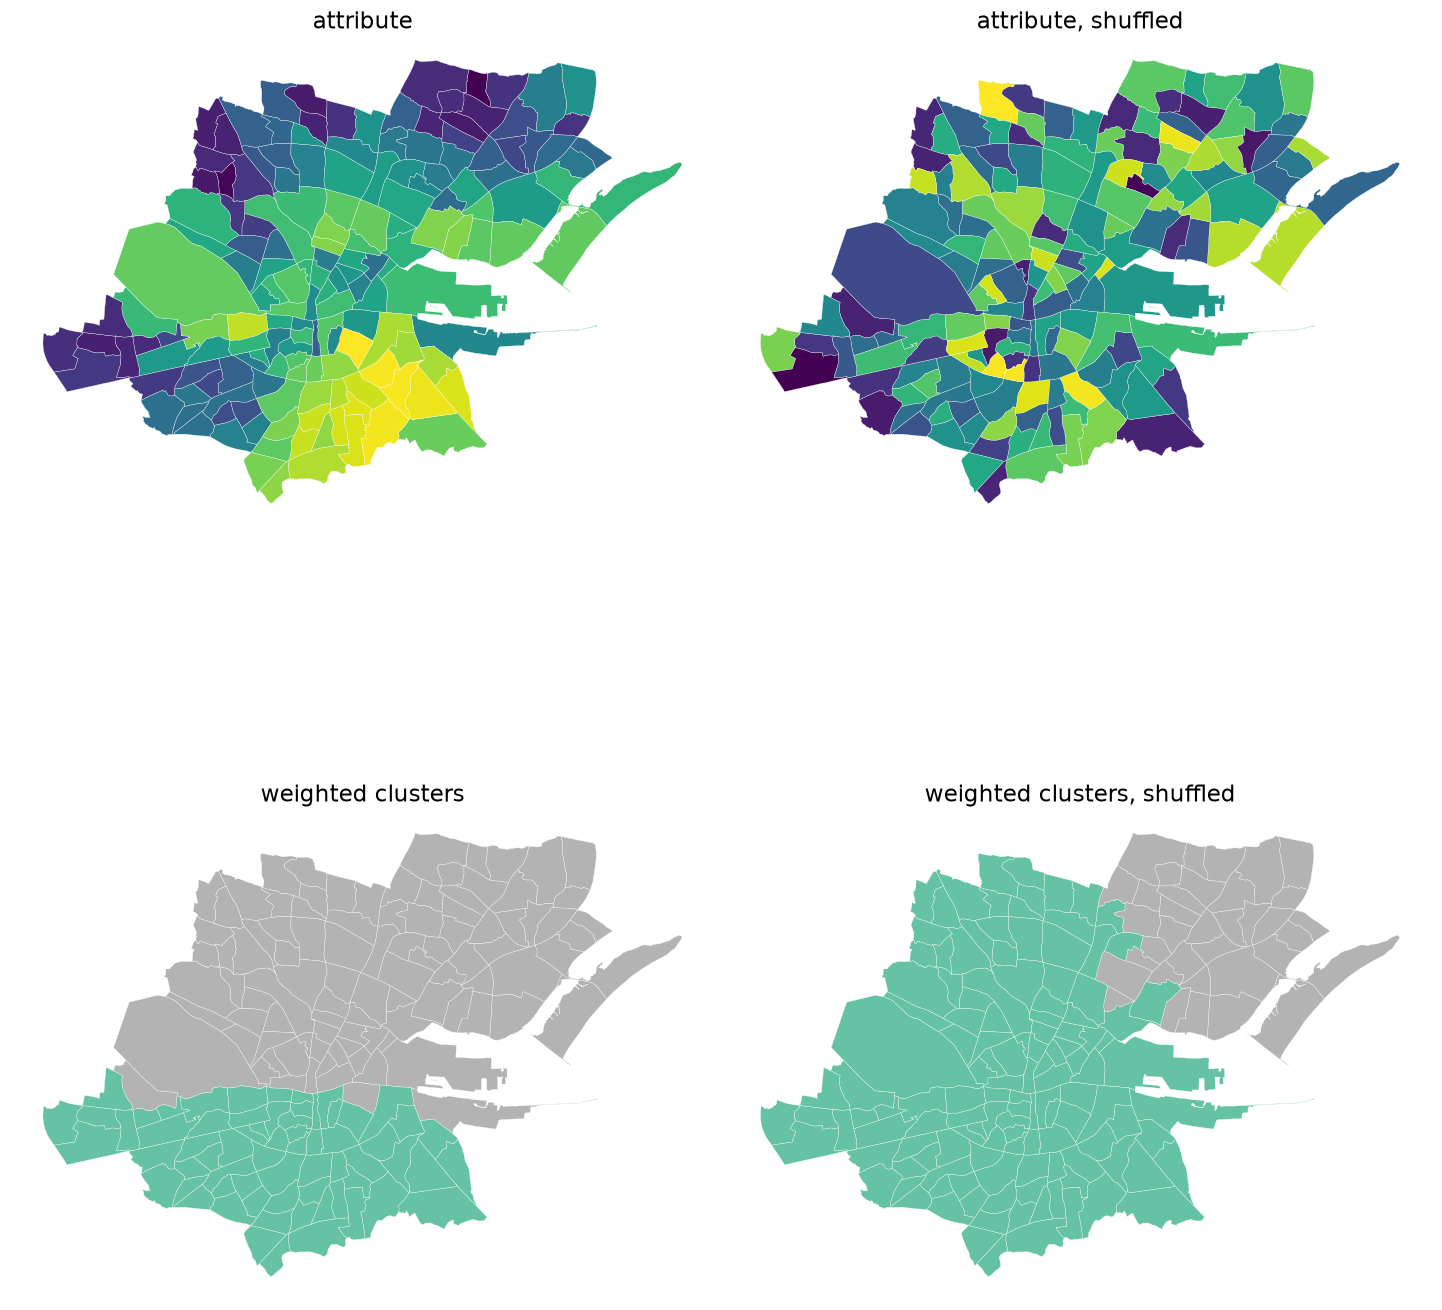

In [24]:
# INSTRUCTOR
# Angle B, and a good closer if the capstone finishes early. Same 162 values, same 162
# polygons, pairing broken.
# Moran's I collapses to roughly its null expectation and the p-value goes flat, as it
# must. The interesting half is the bottom-right map: the weighted clustering still
# returns two contiguous-looking regions, because the contiguity graph is still intact
# and geography alone will always produce something map-shaped.
# The lesson to state plainly: a clustering algorithm always returns clusters. Angle A's
# null and this shuffle are two different ways of asking whether they mean anything.

# Keep the 162 values and the 162 polygons, and break the pairing between them.
# Anything that survives this was never about geography in the first place.
shuffled = RNG.permutation(y)
zs = (shuffled - shuffled.mean()) / shuffled.std(ddof=0)


def weighted_split(values, sigma):
    Wm = np.zeros((n, n))
    for i, j in G.edges():
        Wm[i, j] = Wm[j, i] = np.exp(-((values[i] - values[j]) ** 2) / (2 * sigma ** 2))
    Dm = np.diag(Wm.sum(axis=1))
    return (eigh(Dm - Wm, Dm)[1][:, 1] > 0).astype(int)


mi_shuffled = Moran(shuffled, w, permutations=PERMUTATIONS)
labels_shuffled = weighted_split(zs, SIGMA)

print(f"Moran's I   before {mi.I:+.4f} (p = {mi.p_sim:.3f})   after {mi_shuffled.I:+.4f} (p = {mi_shuffled.p_sim:.3f})")
print(f"cluster sizes before {np.bincount(labels_weighted)}   after {np.bincount(labels_shuffled)}")

fig, axes = plt.subplots(2, 2, figsize=(13, 14))
for ax, col, cmap, title in [
    (axes[0, 0], y, "viridis", "attribute"),
    (axes[0, 1], shuffled, "viridis", "attribute, shuffled"),
]:
    gdf.assign(_v=col).plot(column="_v", cmap=cmap, ax=ax, edgecolor="white", linewidth=0.2)
    ax.set_title(title)
for ax, lab, title in [
    (axes[1, 0], labels_weighted, "weighted clusters"),
    (axes[1, 1], labels_shuffled, "weighted clusters, shuffled"),
]:
    gdf.assign(_l=lab).plot(column="_l", categorical=True, cmap="Set2", ax=ax,
                            edgecolor="white", linewidth=0.2)
    ax.set_title(title)
for ax in axes.ravel():
    ax.set_axis_off()
plt.show()

## 5. Wrap-up (2:15)

Slides.